Name:- Sarthak Zunjure

Roll no:- 03

PRN no:- 1252090003

10. Assignment on Regression technique.

Download temperature data from the link below.

https://www.kaggle.com/venky73/temperaturesof-india?select=temperatures.csv

This data consists of temperatures of INDIA averaging the temperatures of all places month wise. Temperatures values are recorded in CELSIUS

Apply Linear Regression using a suitable library function and predict the Month-wise temperature.
Assess the performance of regression models using MSE, MAE and R-Square   
metrics
Visualize a simple regression model.

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Step 2: Load Dataset

In [ ]:
df = pd.read_csv("temperatures.csv")
print(df.head())

   YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
0  1901  22.40  24.14  29.07  31.91  33.41  33.18  31.21  30.39  30.47  29.97   
1  1902  24.93  26.58  29.77  31.78  33.73  32.91  30.92  30.73  29.80  29.12   
2  1903  23.44  25.03  27.83  31.39  32.91  33.00  31.34  29.98  29.85  29.04   
3  1904  22.50  24.73  28.21  32.02  32.64  32.07  30.36  30.09  30.04  29.20   
4  1905  22.00  22.83  26.68  30.01  33.32  33.25  31.44  30.68  30.12  30.67   

     NOV    DEC  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  
0  27.31  24.49   28.96    23.27    31.46    31.27    27.25  
1  26.31  24.04   29.22    25.75    31.76    31.09    26.49  
2  26.08  23.65   28.47    24.24    30.71    30.92    26.26  
3  26.36  23.63   28.49    23.62    30.95    30.66    26.40  
4  27.52  23.82   28.30    22.25    30.00    31.33    26.57  


Step 3: Data Preprocessing

In [ ]:
month_map = {
    'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
    'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12
}
month_columns = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

id_vars = [col for col in df.columns if col not in month_columns]

df_melted = df.melt(id_vars=id_vars,
                    value_vars=month_columns,
                    var_name='Month_Name',
                    value_name='Temperature')
df_melted['Month'] = df_melted['Month_Name'].str.title().map(month_map)

df = df_melted
print(df.head())

   YEAR  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC Month_Name  Temperature  \
0  1901   28.96    23.27    31.46    31.27    27.25        JAN        22.40   
1  1902   29.22    25.75    31.76    31.09    26.49        JAN        24.93   
2  1903   28.47    24.24    30.71    30.92    26.26        JAN        23.44   
3  1904   28.49    23.62    30.95    30.66    26.40        JAN        22.50   
4  1905   28.30    22.25    30.00    31.33    26.57        JAN        22.00   

   Month  
0      1  
1      1  
2      1  
3      1  
4      1  


In [ ]:
df.isnull().sum()
df.dropna(inplace=True)

Step 4: Define Features & Target

In [ ]:
X = df[['Month']]   # Independent variable
y = df['Temperature']   # Dependent variable

Step 5: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Step 6: Apply Linear Regression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Step 7: Predictions

In [ ]:
y_pred = model.predict(X_test)

Step 8: Model Evaluation

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 9.999806682283973
MAE: 2.705271869781447
R2 Score: -0.005573628993982727


Step 9: Visualization

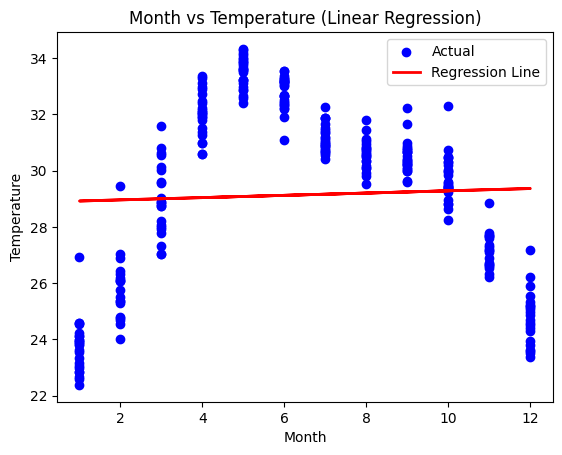

In [ ]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Month")
plt.ylabel("Temperature")
plt.title("Month vs Temperature (Linear Regression)")
plt.legend()
plt.show()

Step 10: Predict Future Values

In [ ]:
pred = model.predict([[5]])
print("Predicted Temperature for May:", pred[0])

Predicted Temperature for May: 29.08214986159124


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
